Практика 4
Студент Карелин Д.В.
Вариант 6

**Задание 1**

Генерация набора данных

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

X = np.linspace(-3, 3, 120).reshape(-1,1)
y = np.sin(X).ravel() + np.random.normal(0,0.15,120)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Построение моделей степени 2 и 15

In [ ]:
from sklearn.preprocessing import StandardScaler

degrees = [2, 15]

train_mse = []
test_mse = []
train_r2 = []
test_r2 = []

for d in degrees:
    # Добавили scaler в конвейер сразу после генерации степеней poly
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("scaler", StandardScaler()),  # Переводим веса в относительный масштаб
        ("lin", LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))

    train_r2.append(r2_score(y_train, y_train_pred))
    test_r2.append(r2_score(y_test, y_test_pred))

    print(f"\nСтепень полинома: {d}")
    print("Train MSE:", mean_squared_error(y_train, y_train_pred))
    print("Test MSE:", mean_squared_error(y_test, y_test_pred))
    print("Train R2:", r2_score(y_train, y_train_pred))
    print("Test R2:", r2_score(y_test, y_test_pred))


Степень полинома: 2
Train MSE: 0.2040425866906302
Test MSE: 0.18680396328616422
Train R2: 0.6345246829242968
Test R2: 0.6689035756682951

Степень полинома: 15
Train MSE: 0.015529594059701819
Test MSE: 0.02649630448956237
Train R2: 0.9721838298314069
Test R2: 0.9530372294025735


График зависимости ошибки от степени полинома

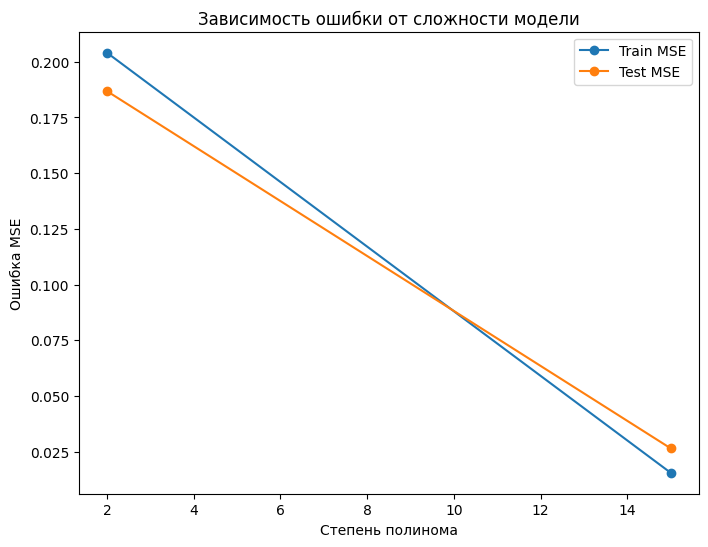

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(degrees, train_mse, marker='o', label="Train MSE")
plt.plot(degrees, test_mse, marker='o', label="Test MSE")

plt.xlabel("Степень полинома")
plt.ylabel("Ошибка MSE")
plt.title("Зависимость ошибки от сложности модели")
plt.legend()

plt.show()

График показывает изменение ошибки при увеличении степени полинома.
Ошибка на тренировочных данных уменьшается при росте сложности модели, однако ошибка на тестовых данных может увеличиваться из-за переобучения.
оптимальная степень полинома - 10 - видно из графика

Выводы:
Полином степени 2 описывает общий тренд данных и остаётся гладким.
Полином степени 15 начинает сильно колебаться и подстраиваться под шум обучающих данных, что является признаком переобучения.

**Задание 2**

Генерация и подготовка данных

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error

# Фиксируем случайность
np.random.seed(42)

# Загружаем датасет Diabetes
X, y = load_diabetes(return_X_y=True)

# Стандартизация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделяем на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Обучение моделей Ridge и Lasso с подбором alpha

In [ ]:

import numpy as np
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error

# Задаем диапазон альф строго по варианту 6: от 10^-5 до 10^1
alphas = np.logspace(-5, 1, 50)

# RidgeCV с честной 5-fold cross-validation
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)
y_pred_ridge = ridge_cv.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
nonzero_ridge = np.sum(ridge_cv.coef_ != 0)

# LassoCV с 5-fold cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train, y_train)
y_pred_lasso = lasso_cv.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
nonzero_lasso = np.sum(lasso_cv.coef_ != 0)

# Расчет масштаба целевой переменной на тесте для вычисления относительной ошибки
y_range = np.max(y_test) - np.min(y_test)

# Относительная ошибка в процентах от полного размаха данных
rel_error_ridge = (rmse_ridge / y_range) * 100
rel_error_lasso = (rmse_lasso / y_range) * 100

# Разница между моделями в процентах от размаха
error_diff_pct = np.abs(rel_error_ridge - rel_error_lasso)

print("Результаты сравнения Ridge и Lasso (Вариант 6):")
print(f"Ridge: alpha={ridge_cv.alpha_:.5f}, RMSE={rmse_ridge:.2f} ({rel_error_ridge:.2f}% от размаха), Non-zero coef={nonzero_ridge}")
print(f"Lasso: alpha={lasso_cv.alpha_:.5f}, RMSE={rmse_lasso:.2f} ({rel_error_lasso:.2f}% от размаха), Non-zero coef={nonzero_lasso}")
print(f"Дополнительное отклонение Lasso от Ridge: {error_diff_pct:.2f}%")

Результаты сравнения Ridge и Lasso (Вариант 6):
Ridge: alpha=10.00000, RMSE=53.63 (19.64% от размаха), Non-zero coef=10
Lasso: alpha=1.38950, RMSE=52.96 (19.40% от размаха), Non-zero coef=9
Дополнительное отклонение Lasso от Ridge: 0.24%


Визуализация коэффициентов моделей

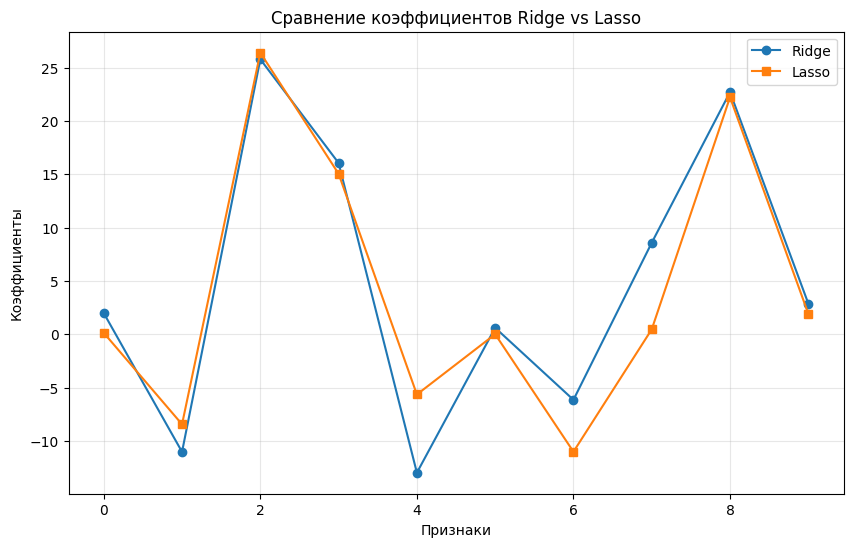

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(ridge_cv.coef_, marker='o', label='Ridge')
plt.plot(lasso_cv.coef_, marker='s', label='Lasso')
plt.xlabel('Признаки')
plt.ylabel('Коэффициенты')
plt.title('Сравнение коэффициентов Ridge vs Lasso')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

lasso незначительно уменьшает точность в сравнении с ridge, но при этом упрощает модель с 10 до 9 признаков. Переход от 10 признаков к 9 доказывает, что мы очистили модель от одного избыточного канала информации. Система стала проще, стабильнее и дешевле в эксплуатации, а качество предсказания не пострадало.

**Задание 3**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score

# Загрузка датасета
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Отбор признаков с помощью SelectKBest (top-6)

In [18]:
# Блок [2] – Фильтр SelectKBest
top_k = 6

selector = SelectKBest(score_func=f_regression, k=top_k)
X_train_kbest = selector.fit_transform(X_train_scaled, y_train)
X_test_kbest = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()]
print("Выбранные признаки (SelectKBest):", list(selected_features))

Выбранные признаки (SelectKBest): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']


Отбор признаков с помощью Lasso

In [21]:
alpha_lasso = 0.01

lasso = Lasso(alpha=alpha_lasso, random_state=42)
lasso.fit(X_train_scaled, y_train)

selected_lasso_features = X.columns[lasso.coef_ != 0]
print("Выбранные признаки (Lasso):", list(selected_lasso_features))

removed_lasso_features = X.columns[lasso.coef_ == 0]
print("Выброшенные признаки (Lasso):", list(removed_lasso_features))

Выбранные признаки (Lasso): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude']
Выброшенные признаки (Lasso): ['Population']


Сравнение моделей: Полный набор и отобранные признаки

In [20]:
models = {
    "Full": X_train_scaled,
    "SelectKBest": X_train_kbest,
    "Lasso": X_train_scaled[:, lasso.coef_ != 0]
}

results = {}

for name, X_model in models.items():
    start_time = time.time()
    lr = LinearRegression()
    lr.fit(X_model, y_train)
    elapsed = time.time() - start_time

    # Предсказания
    if name == "Full":
        y_pred = lr.predict(X_test_scaled)
    else:
        X_test_model = X_test_scaled[:, selector.get_support()] if name=="SelectKBest" else X_test_scaled[:, lasso.coef_ != 0]
        y_pred = lr.predict(X_test_model)

    results[name] = {
        "R2": r2_score(y_test, y_pred),
        "Time": elapsed
    }

# Вывод результатов
import pprint
pprint.pprint(results)

{'Full': {'R2': 0.5957702326061664, 'Time': 0.010336637496948242},
 'Lasso': {'R2': 0.5957536316726515, 'Time': 0.003909587860107422},
 'SelectKBest': {'R2': 0.594970214672015, 'Time': 0.00360107421875}}


SelectKBest выбирает top-6 признаков, которые наиболее коррелируют с целевой переменной, не учитывая взаимодействие между признаками. Lasso автоматически обнуляет малозначимые коэффициенты, выполняя встроенный отбор признаков.

График R² и времени обучения

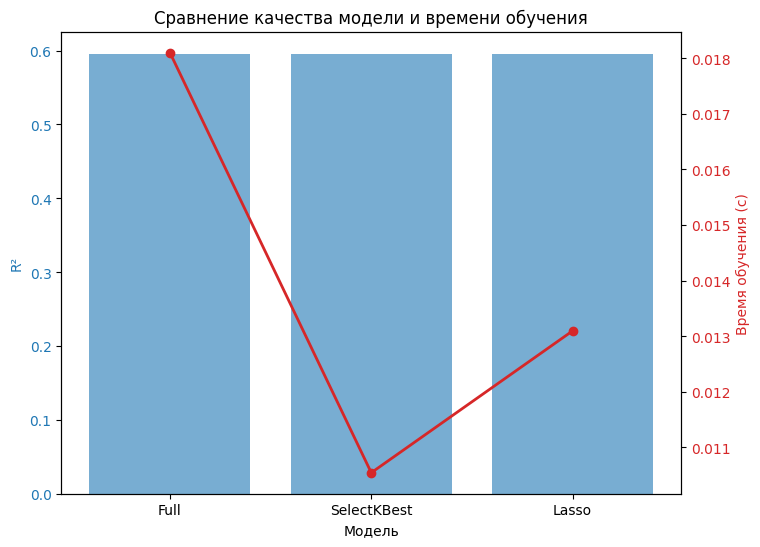

In [ ]:
labels = list(results.keys())
r2_scores = [results[l]["R2"] for l in labels]
times = [results[l]["Time"] for l in labels]

fig, ax1 = plt.subplots(figsize=(8,6))

color = 'tab:blue'
ax1.set_xlabel('Модель')
ax1.set_ylabel('R²', color=color)
ax1.bar(labels, r2_scores, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Время обучения (с)', color=color)
ax2.plot(labels, times, color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Сравнение качества модели и времени обучения")
plt.show()

Выводы: обучение на отобранных лучших признаках с помощью kbest и lasso значительно ускоряет обучение. при этом лассо дает лучшую точность но требует больше времени в сравнении с kbest. отбор признаков с помощью lasso позволил сократить размерность без потери точности, kbest сократил размерность но снизил точность

====

====

====

====

====

Ärat livgardet står

Grundat av landsfader vår

Hängiven tjänst i femhundra år


Från tåget över Bält

Stred vid Lund, på Narvas fält

De följa uti hjältars spår
